# VIF Filtering for Dataset

Results will be uploaded into VIF_test.csv, and if it works out well then I'll make VIF_counts.csv and VIF_percents.csv

### Import Libraries

In [39]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

### Import test dataset (jolts_counts.csv)

In [40]:
jolts_counts = pd.read_csv('data/jolts_counts_not_seasonally_adjusted.csv')

jolts_counts = jolts_counts.drop(['date', 'Unnamed: 0'], axis=1)

jolts_counts.head()

,"Hires: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Hires: Total nonfarm in Alabama - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm in Alabama - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm in Alabama - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: Total nonfarm in Alabama - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)",...,"Layoffs and Discharges: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Hires: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)"
0,4141.0,4335.0,2295.0,313.0,2331.0,4939.0,53.0,55.0,27.0,32.0,...,42.0,11.0,45.0,98.0,105.0,277.0,44.0,19.0,52.0,115.0
1,5707.0,5592.0,2965.0,549.0,3425.0,6938.0,84.0,78.0,35.0,49.0,...,22.0,16.0,58.0,96.0,127.0,255.0,33.0,23.0,56.0,112.0
2,4376.0,4844.0,1495.0,264.0,2472.0,4231.0,58.0,68.0,23.0,37.0,...,19.0,11.0,40.0,70.0,124.0,242.0,27.0,16.0,72.0,115.0
3,5069.0,4514.0,1614.0,321.0,2615.0,4549.0,80.0,57.0,25.0,38.0,...,13.0,11.0,45.0,69.0,128.0,243.0,26.0,17.0,68.0,111.0
4,5842.0,5095.0,1834.0,371.0,3312.0,5517.0,96.0,75.0,28.0,53.0,...,12.0,12.0,34.0,59.0,143.0,288.0,48.0,22.0,57.0,127.0


### Start VIF Filtering

In [41]:
# VIF Filter jolts_counts

X_vif = add_constant(jolts_counts)
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                    for i in range(X_vif.shape[1])]
print("Initial VIFs:\n", vif_data)

C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Initial VIFs:
                                                feature  VIF
0                                                const  0.0
1    Hires: Total nonfarm - Level in Thousands, Mon...  inf
2    Job Openings: Total nonfarm - Level in Thousan...  inf
3    Layoffs and Discharges: Total nonfarm - Level ...  inf
4    Other separations: Total nonfarm - Level in Th...  inf
..                                                 ...  ...
479  Job Openings: State and local government, excl...  inf
480  Layoffs and Discharges: State and local govern...  inf
481  Other separations: State and local government,...  inf
482  Quits: State and local government, excluding e...  inf
483  Total Separations: State and local government,...  inf

[484 rows x 2 columns]


In [42]:
print(list(jolts_counts.columns))

['Hires: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)', 'Job Openings: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)', 'Layoffs and Discharges: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)', 'Other separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)', 'Quits: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)', 'Total Separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)', 'Hires: Total nonfarm in Alabama - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)', 'Job Openings: Total nonfarm in Alabama - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)', 'Layoffs and Discharges: Total nonfarm in Alabama - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)', 'Quits: Tota

### Addressing Multicollinearity

So, since every column is being highlighted as multicollinear, I have to have different scopes for VIF filtering.

In [43]:
def calculate_vif_for_scope(X):
    X_vif = sm.add_constant(X, has_constant='add')
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_vif.columns

    try:
        vif_data["VIF"] = [
            variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])
        ]
        
    except np.linalg.LinAlgError:
        print("\n--- WARNING: Linear Algebra Error (Perfect Multicollinearity persists) ---")
        print("Check if the filtered subset still contains a 'Total' column and all its components.")
        vif_data["VIF"] = "Error"
    
    return vif_data.sort_values(by="VIF", ascending=False)

In [44]:
### National Scope VIF Filtering

national_scope = [
    col for col in jolts_counts.columns
    if "Total nonfarm -" in col and not any(
        s in col for s in ['State and local', 'Federal', 'Private']
    )
]

X_national = jolts_counts[national_scope].copy()

vif_national_df = calculate_vif_for_scope(X_national)

print("="*50)
print("VIF for Scope 1: National Totals")
print(vif_national_df)
print("="*50)

VIF for Scope 1: National Totals
                                             feature           VIF
6  Total Separations: Total nonfarm - Level in Th...  7.601442e+06
3  Layoffs and Discharges: Total nonfarm - Level ...  5.830124e+06
5  Quits: Total nonfarm - Level in Thousands, Mon...  1.542692e+06
4  Other separations: Total nonfarm - Level in Th...  9.055734e+03
0                                              const  6.189270e+01
1  Hires: Total nonfarm - Level in Thousands, Mon...  5.030291e+00
2  Job Openings: Total nonfarm - Level in Thousan...  4.048630e+00


In [45]:
X_national.head()

,"Hires: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Total Separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)"
0,4141.0,4335.0,2295.0,313.0,2331.0,4939.0
1,5707.0,5592.0,2965.0,549.0,3425.0,6938.0
2,4376.0,4844.0,1495.0,264.0,2472.0,4231.0
3,5069.0,4514.0,1614.0,321.0,2615.0,4549.0
4,5842.0,5095.0,1834.0,371.0,3312.0,5517.0


In [52]:
granular_columns = [
    col for col in jolts_counts.columns
    if not any(s in col for s in ['Total nonfarm', 'Total Industry', 'All Industry', 'const', 'date', 'Total']) and
    jolts_counts[col].dtype in ['int64', 'float64']
]

X_granular = jolts_counts[granular_columns].copy()

vif_granular_df = calculate_vif_for_scope(X_granular)

print("="*50)
print("VIF for Scope 3: Granular (State x Industry) Data")
print(vif_granular_df)
print("="*50)

VIF for Scope 3: Granular (State x Industry) Data
                                               feature           VIF
88   Layoffs and Discharges: Leisure and hospitalit...  3.583089e+06
98   Layoffs and Discharges: Accommodation and food...  2.876365e+06
72   Job Openings: Private education and health ser...  2.031884e+06
82   Job Openings: Health care and social assistanc...  1.695656e+06
27   Job Openings: Trade, transportation, and utili...  1.257983e+06
..                                                 ...           ...
69   Other separations: Professional and business s...  3.363386e+00
4    Other separations: Mining and logging - Level ...  3.243619e+00
49   Other separations: Information - Level in Thou...  2.852699e+00
104  Other separations: Other services - Level in T...  2.357521e+00
9    Other separations: Construction - Level in Tho...  2.221403e+00

[131 rows x 2 columns]


In [53]:
X_granular.head()

,"Hires: Mining and logging - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: Mining and logging - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: Mining and logging - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: Mining and logging - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: Mining and logging - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Hires: Construction - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: Construction - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: Construction - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: Construction - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: Construction - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)",...,"Hires: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Hires: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Job Openings: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Layoffs and Discharges: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Other separations: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)","Quits: State and local government, excluding education - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)"
0,16.0,7.0,22.0,0.0,5.0,263.0,172.0,384.0,24.0,71.0,...,75.0,133.0,42.0,11.0,45.0,105.0,277.0,44.0,19.0,52.0
1,25.0,13.0,13.0,3.0,11.0,433.0,223.0,348.0,28.0,145.0,...,145.0,133.0,22.0,16.0,58.0,127.0,255.0,33.0,23.0,56.0
2,16.0,8.0,5.0,4.0,5.0,380.0,211.0,285.0,7.0,146.0,...,128.0,142.0,19.0,11.0,40.0,124.0,242.0,27.0,16.0,72.0
3,26.0,17.0,8.0,2.0,9.0,556.0,189.0,256.0,21.0,161.0,...,88.0,133.0,13.0,11.0,45.0,128.0,243.0,26.0,17.0,68.0
4,24.0,18.0,8.0,1.0,13.0,634.0,285.0,169.0,30.0,236.0,...,83.0,141.0,12.0,12.0,34.0,143.0,288.0,48.0,22.0,57.0


### FULL VIF AND Feature Drop Implementation

In [48]:
def drop_redundant_vif_features(df, threshold=5.0):
    """
    Calculates VIF iteratively and removes the feature with the highest VIF 
    until all remaining VIFs are below the specified threshold.
    
    Args:
        df (pd.DataFrame): The DataFrame containing only the numeric features 
                           (no aggregates/totals, no dates/strings).
        threshold (float): The maximum acceptable VIF value.
        
    Returns:
        pd.DataFrame: The DataFrame containing only the selected features.
        pd.DataFrame: A table of the final VIF results.
    """
    # Start with the full, clean DataFrame (only numeric features)
    X = df.copy()
    
    # Drop the 'Unnamed: 0' column if it exists (it was a high-VIF culprit)
    if 'Unnamed: 0' in X.columns:
        X = X.drop(columns=['Unnamed: 0'])

    while True:
        # Add a constant for VIF calculation
        X_vif = sm.add_constant(X)
        
        # Calculate VIFs
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_vif.columns
        vif_data["VIF"] = [
            variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])
        ]
        
        # Sort and exclude the 'const' term
        vif_data = vif_data[vif_data['feature'] != 'const'].sort_values(
            by="VIF", ascending=False
        )
        
        # Check the highest VIF value
        max_vif = vif_data["VIF"].iloc[0] if not vif_data.empty else 0
        feature_to_drop = vif_data["feature"].iloc[0] if not vif_data.empty else None

        if max_vif > threshold:
            # Drop the feature with the highest VIF
            print(f"Dropping '{feature_to_drop}' (VIF: {max_vif:.2f})")
            X = X.drop(columns=[feature_to_drop])
        else:
            # All VIFs are now below the threshold
            print("\nAll VIFs are now below the threshold.")
            return X, vif_data
            
    return X, vif_data # Should be unreachable, but good practice

In [50]:
### Try it on X_national first for testing purposes

X_national_filtered, vif_national_final = drop_redundant_vif_features(X_national, threshold=5.0)

X_national_filtered.head()
vif_national_final

Dropping 'Total Separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 7601441.89)
Dropping 'Quits: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 9.29)

All VIFs are now below the threshold.


,feature,VIF
1,"Hires: Total nonfarm - Level in Thousands, Mon...",2.421701
2,Job Openings: Total nonfarm - Level in Thousan...,2.148553
4,Other separations: Total nonfarm - Level in Th...,1.228953
3,Layoffs and Discharges: Total nonfarm - Level ...,1.018350


### Results: This is type stuff dude

In [51]:
### Addressing Multicollinearity in JOLTS Data Using VIF Filtering

### Try it on X_granular next for testing purposes
X_granular_filtered, vif_granular_final = drop_redundant_vif_features(X_granular, threshold=10.0)
X_granular_filtered.head()
vif_granular_final

Dropping 'Total Separations: Total private - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 61323241.69)
Dropping 'Job Openings: Total private - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 36596529.22)
Dropping 'Layoffs and Discharges: Total private - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 26888033.21)
Dropping 'Total Separations: Leisure and hospitality - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 10416535.55)
Dropping 'Layoffs and Discharges: Leisure and hospitality - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 9655844.55)
Dropping 'Hires: Total private - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 6479153.10)
Dropping 'Total Separations: Accommodation and food services - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 5933222.23)
Dropping 'Tot

,feature,VIF
2,"Quits: Total private - Level in Thousands, Mon...",9.781544
25,Layoffs and Discharges: Wholesale trade - Leve...,9.609455
23,"Hires: Wholesale trade - Level in Thousands, M...",9.491903
35,Layoffs and Discharges: Information - Level in...,8.840285
8,"Hires: Total private - Level in Thousands, Mon...",8.670530
...,...,...
45,Other separations: Real estate and rental and ...,1.737541
55,"Other separations: Arts, entertainment, and re...",1.697443
32,"Other separations: Transportation, warehousing...",1.658436
60,Other separations: Other services - Level in T...,1.642136


### Next Steps:
1. I'm going to save this df as a .csv in /data just so I can hold onto it for future reference.
2. I'm going to also plot the correlation matrix of the df and itself.

In [54]:
### save as .csv
X_granular_filtered.to_csv('data/jolts_granular_vif_filtered.csv', index=False)

In [56]:
### Shorten the column names for better visualization (take out everything past - with regex)
X_granular_filtered.columns = X_granular_filtered.columns.str.replace(r' - .*', '', regex=True)

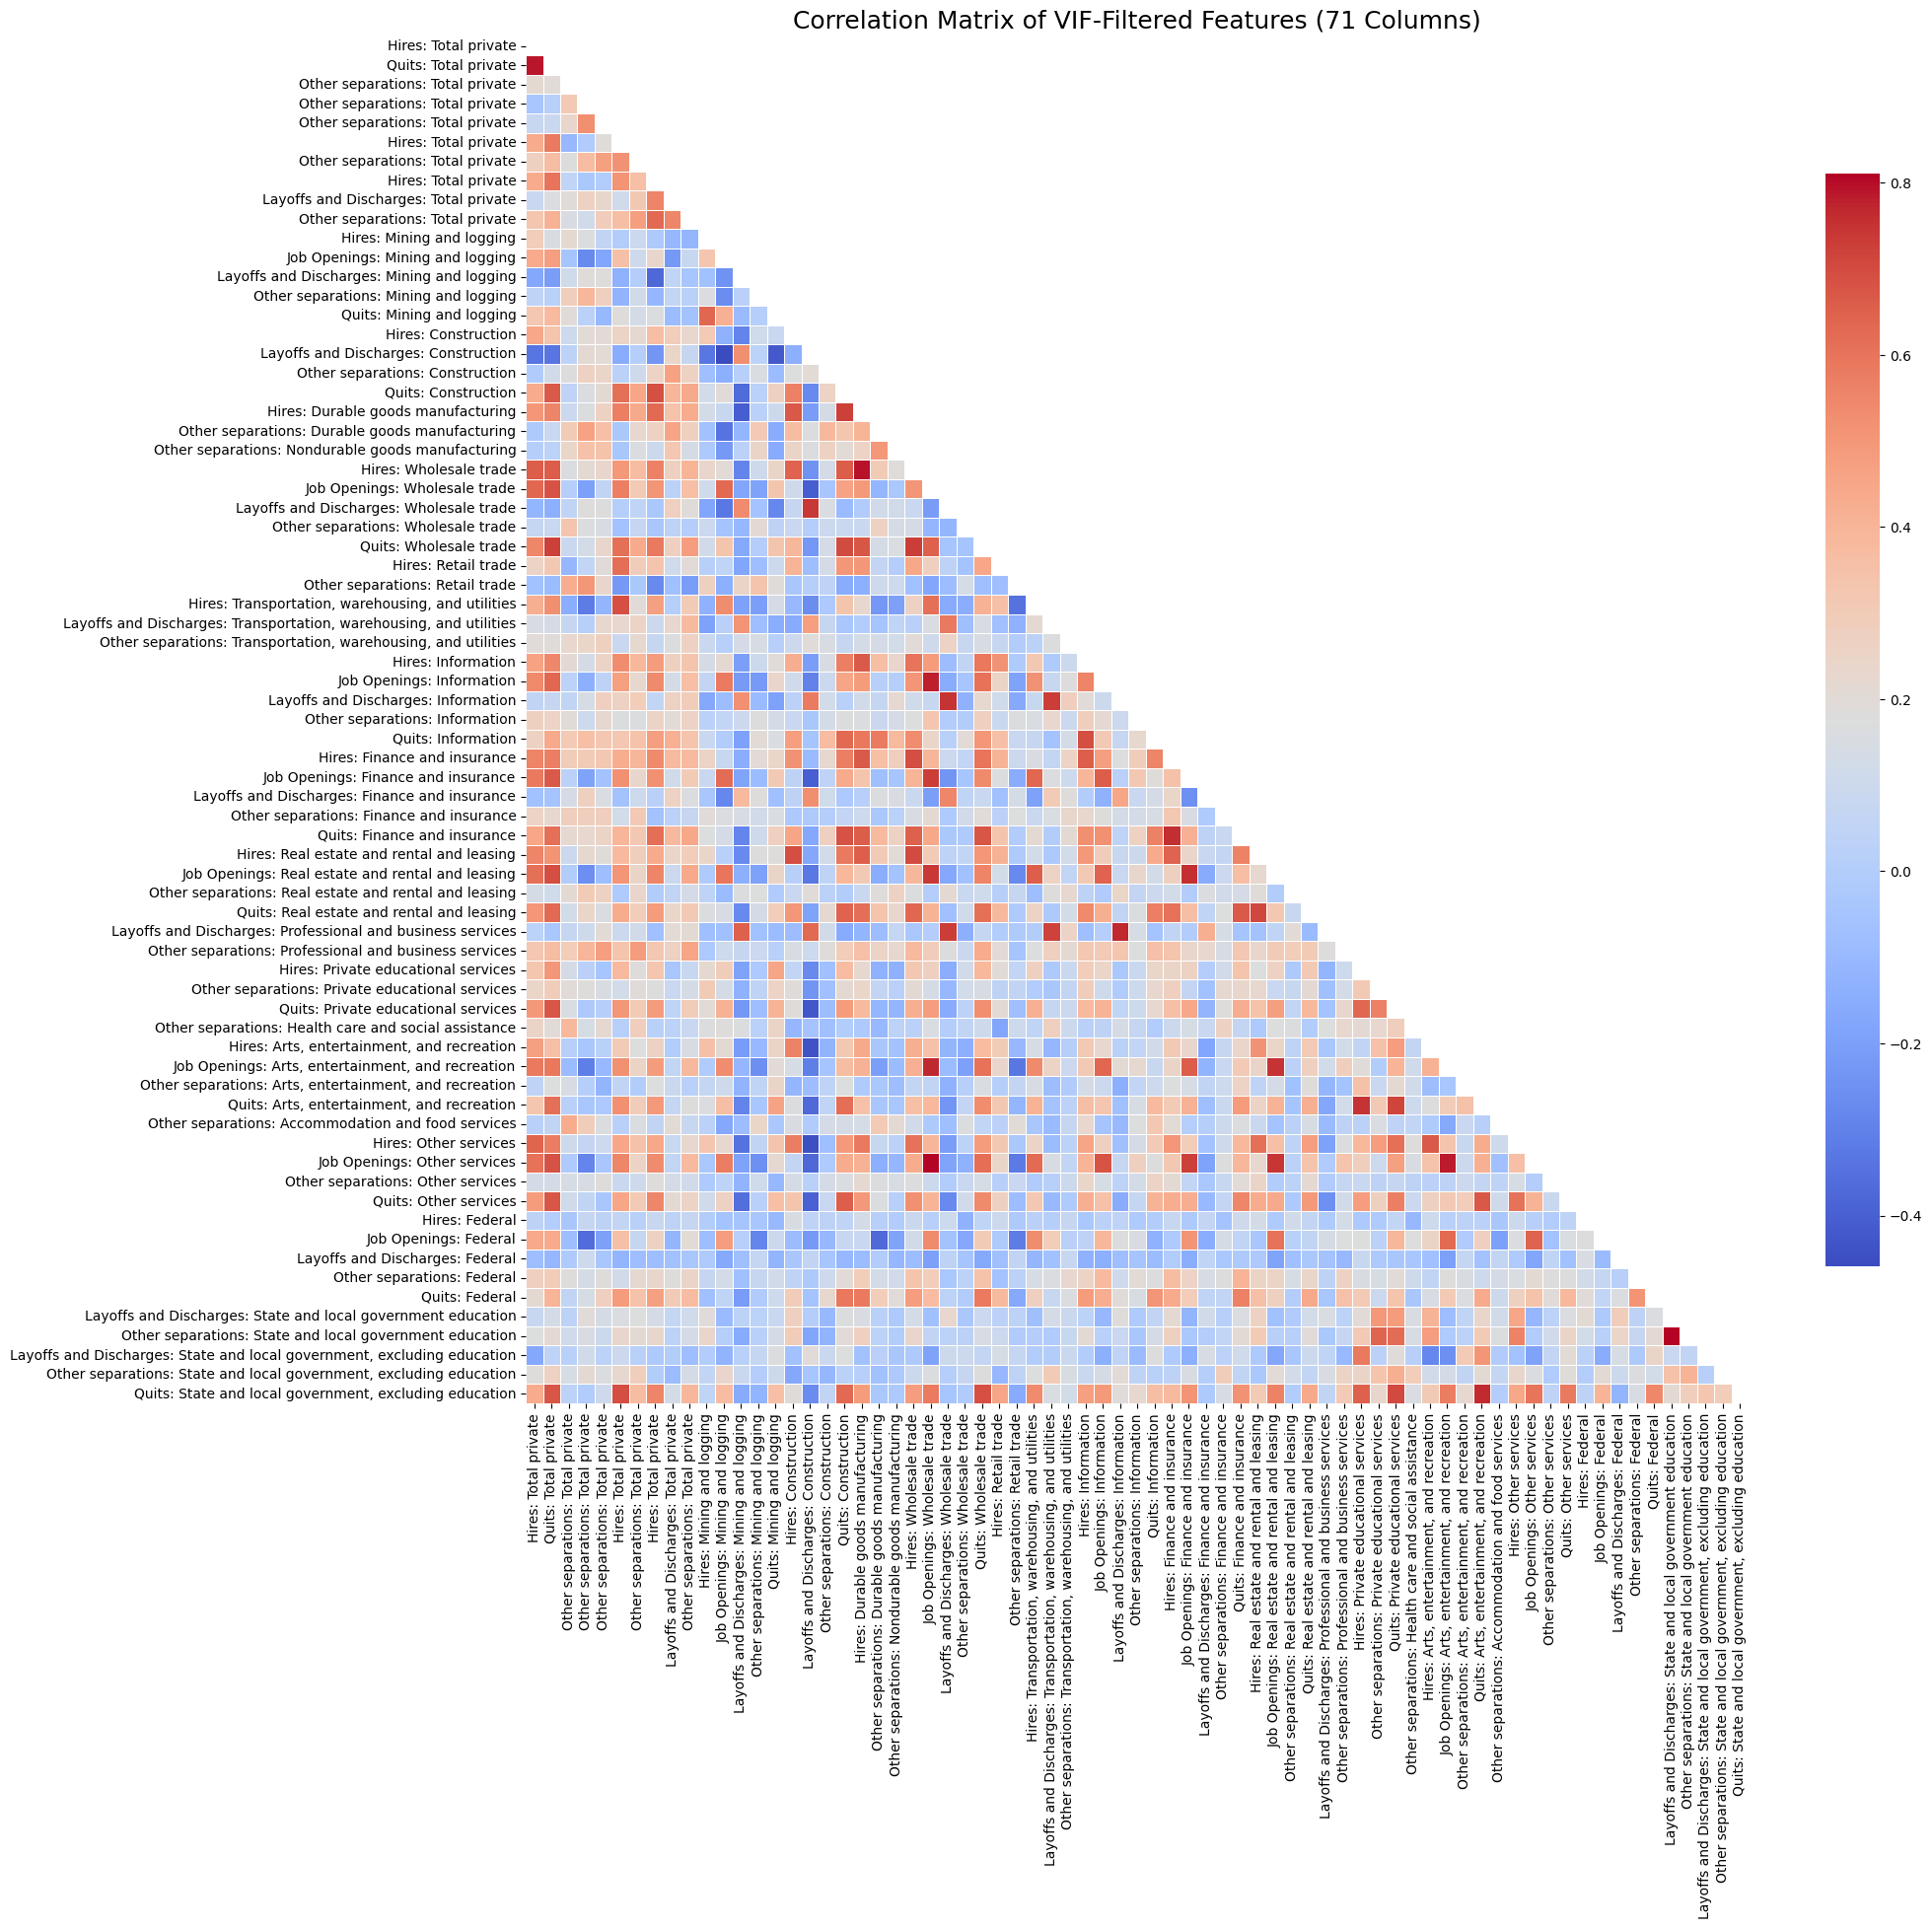

In [59]:
### Plot correlation matrix of filtered granular data
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming final_features_df is the cleaned DataFrame from the VIF function

# 1. Calculate the correlation matrix
corr_matrix = X_granular_filtered.corr()

# 2. Set up the figure size
plt.figure(figsize=(20, 18))

# 3. Create the heatmap
# Use a diverging color map ('coolwarm') and mask the upper triangle for clarity
mask = np.triu(corr_matrix) # Helper to mask the upper triangle

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=False, # Set to True if you want numbers, but with 71 features it's too dense
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Matrix of VIF-Filtered Features (71 Columns)', fontsize=18)
plt.show()

In [64]:
for i in jolts_counts.columns:
    print(i)

Hires: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)
Job Openings: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)
Layoffs and Discharges: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)
Other separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)
Quits: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)
Total Separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)
Hires: Total nonfarm in Alabama - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)
Job Openings: Total nonfarm in Alabama - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)
Layoffs and Discharges: Total nonfarm in Alabama - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)
Quits: Total nonfarm in Alabama - Level 

# SERIOUS VIF (OPM ref)

In [ ]:
# --- Scope 1: Granular Scope (State-Level Totals) ---
# Goal: Keep columns that represent TOTAL NONFARM data for individual states (e.g., 'Hires... in Alabama').
# Logic: Must contain a state name AND contain the TOTAL_NONFARM_INDUSTRY phrase.
#        Must NOT contain any REGION_NAMES or the generic NATIONAL TOTAL phrase without 'in'.

STATE_NAMES = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
REGION_NAMES = ['Midwest region', 'Northeast region', 'South region', 'West region']
TOTAL_NONFARM_INDUSTRY = 'Total nonfarm'

df = jolts_counts.copy()

def contains_any(text, sub_list):
    return any(sub in text for sub in sub_list)

state_total_columns = [
    col for col in df.columns 
    if contains_any(col, STATE_NAMES) and
       TOTAL_NONFARM_INDUSTRY in col and
       not contains_any(col, REGION_NAMES) and
       ' in ' in col # Ensures it's a state breakdown and not the national total
]

X_state = df[state_total_columns].copy()
final_features_df, final_vifs = drop_redundant_vif_features(X_state, threshold=10.0)

final_vifs

Dropping 'Total Separations: Total nonfarm in Nevada - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 24035.45)
Dropping 'Total Separations: Total nonfarm in Minnesota - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 8672.72)
Dropping 'Total Separations: Total nonfarm in California - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 8145.25)
Dropping 'Total Separations: Total nonfarm in Texas - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 5626.41)
Dropping 'Total Separations: Total nonfarm in Florida - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 4949.98)
Dropping 'Total Separations: Total nonfarm in Michigan - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 4492.97)
Dropping 'Total Separations: Total nonfarm in New York - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (V

,feature,VIF
67,Quits: Total nonfarm in West Virginia - Level ...,9.861027
56,Hires: Total nonfarm in South Carolina - Level...,9.641184
50,Quits: Total nonfarm in Oklahoma - Level in Th...,9.609856
52,Layoffs and Discharges: Total nonfarm in Orego...,9.113743
40,Hires: Total nonfarm in New Hampshire - Level ...,9.054859
...,...,...
66,Hires: Total nonfarm in West Virginia - Level ...,4.888578
32,Hires: Total nonfarm in Michigan - Level in Th...,4.681310
12,Hires: Total nonfarm in District of Columbia -...,4.171412
17,Hires: Total nonfarm in Hawaii - Level in Thou...,4.110281


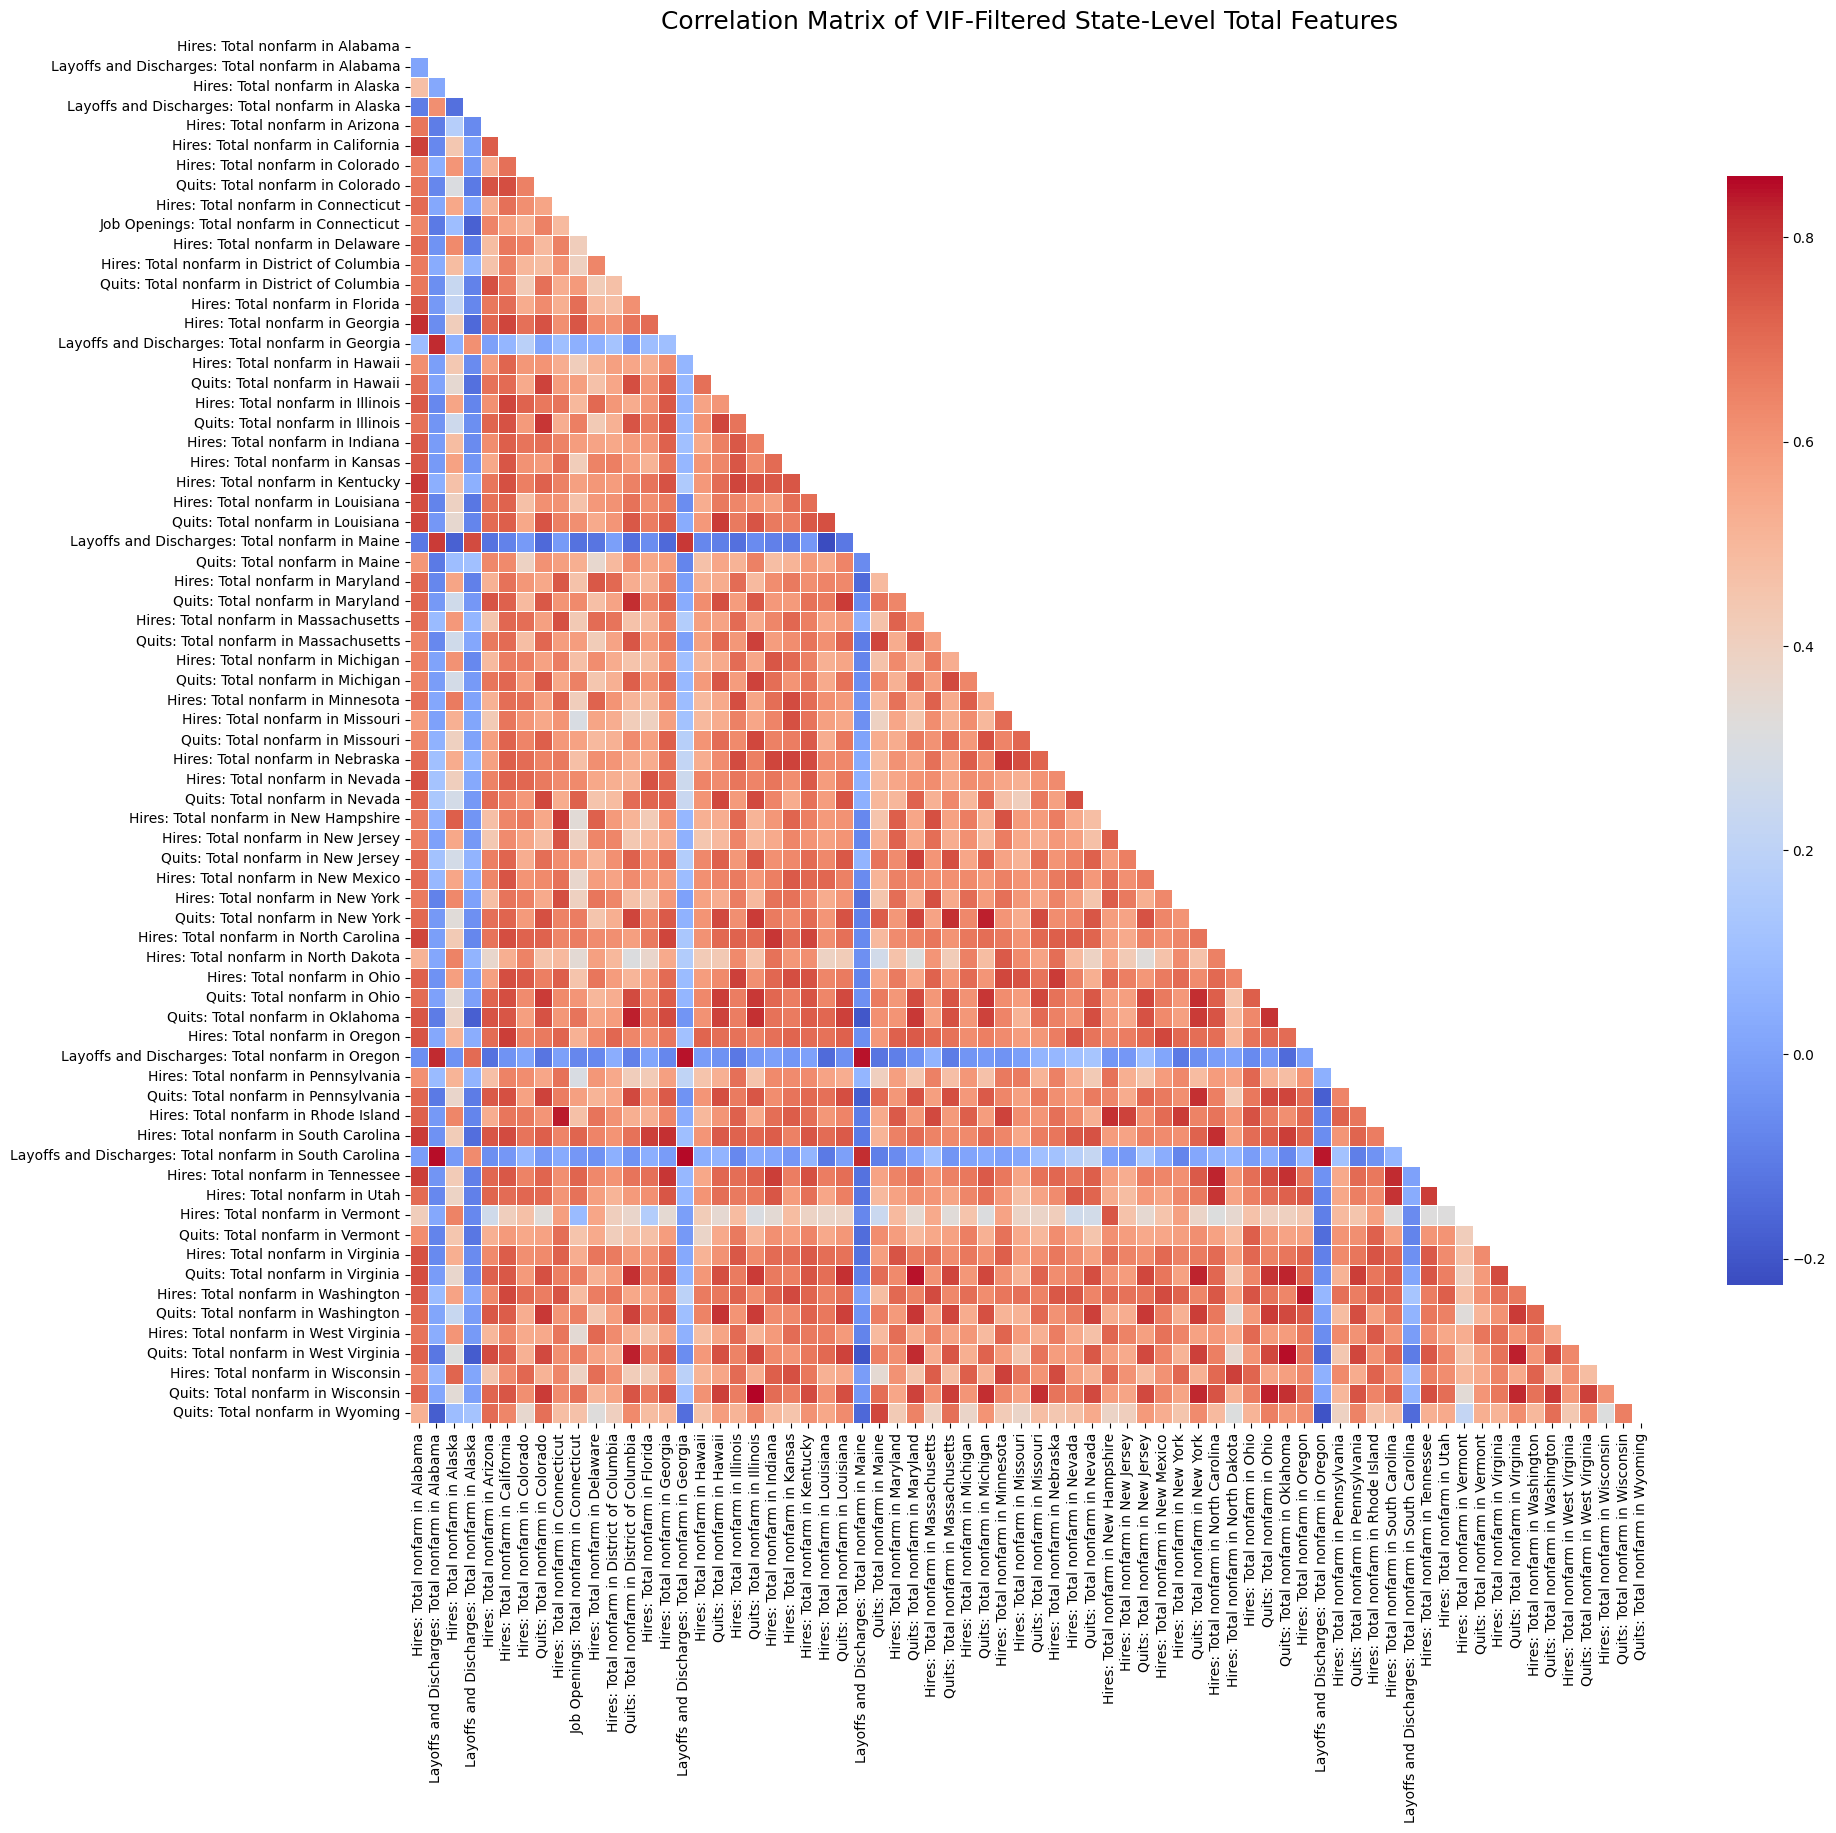

In [69]:
### Create correlation matrix similar to above for state-level totals

# Assuming final_features_df is the cleaned DataFrame from the VIF function
# 1. Calculate the correlation matrix

## 1a. Shorten column names for better visualization
final_features_df.columns = final_features_df.columns.str.replace(r' - .*', '', regex=True)

corr_matrix = final_features_df.corr()
# 2. Set up the figure size
plt.figure(figsize=(20, 18))
# 3. Create the heatmap
# Use a diverging color map ('coolwarm') and mask the upper triangle for clarity   
mask = np.triu(corr_matrix) # Helper to mask the upper triangle
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=False, # Set to True if you want numbers, but with many features it's too dense
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Matrix of VIF-Filtered State-Level Total Features', fontsize=18)
plt.show()

In [96]:
final_features_df.to_csv('data/potential_model_features/state_level_totals.csv', index=False)

In [66]:
# --- Scope 2: Mid-Level Scope (Regional Totals) ---
# Goal: Keep columns that represent TOTAL NONFARM data for the major regions (e.g., 'Hires... in Midwest region').
# Logic: Must contain one of the REGION_NAMES AND contain the TOTAL_NONFARM_INDUSTRY phrase.

regional_total_columns = [
    col for col in df.columns 
    if contains_any(col, REGION_NAMES) and
       TOTAL_NONFARM_INDUSTRY in col
]

X_regional = df[regional_total_columns].copy()
final_features_df_regional, final_vifs_regional = drop_redundant_vif_features(X_regional, threshold=10.0)

final_vifs_regional

Dropping 'Total Separations: Total nonfarm in South region - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 670681.67)
Dropping 'Total Separations: Total nonfarm in West region - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 405167.85)
Dropping 'Total Separations: Total nonfarm in Midwest region - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 385974.05)
Dropping 'Total Separations: Total nonfarm in Northeast region - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 214040.87)
Dropping 'Job Openings: Total nonfarm in South region - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 59.96)
Dropping 'Layoffs and Discharges: Total nonfarm in Midwest region - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 47.30)
Dropping 'Job Openings: Total nonfarm in Midwest region - Level in Thousands, Monthly, Not Seas

,feature,VIF
9,Hires: Total nonfarm in West region - Level in...,7.790244
1,Hires: Total nonfarm in Midwest region - Level...,6.697706
3,Hires: Total nonfarm in Northeast region - Lev...,5.407196
7,Quits: Total nonfarm in Northeast region - Lev...,4.402162
4,Job Openings: Total nonfarm in Northeast regio...,2.685504
8,Other separations: Total nonfarm in South regi...,1.857081
2,Other separations: Total nonfarm in Midwest re...,1.820357
6,Other separations: Total nonfarm in Northeast ...,1.692695
10,Other separations: Total nonfarm in West regio...,1.577977
5,Layoffs and Discharges: Total nonfarm in North...,1.207771


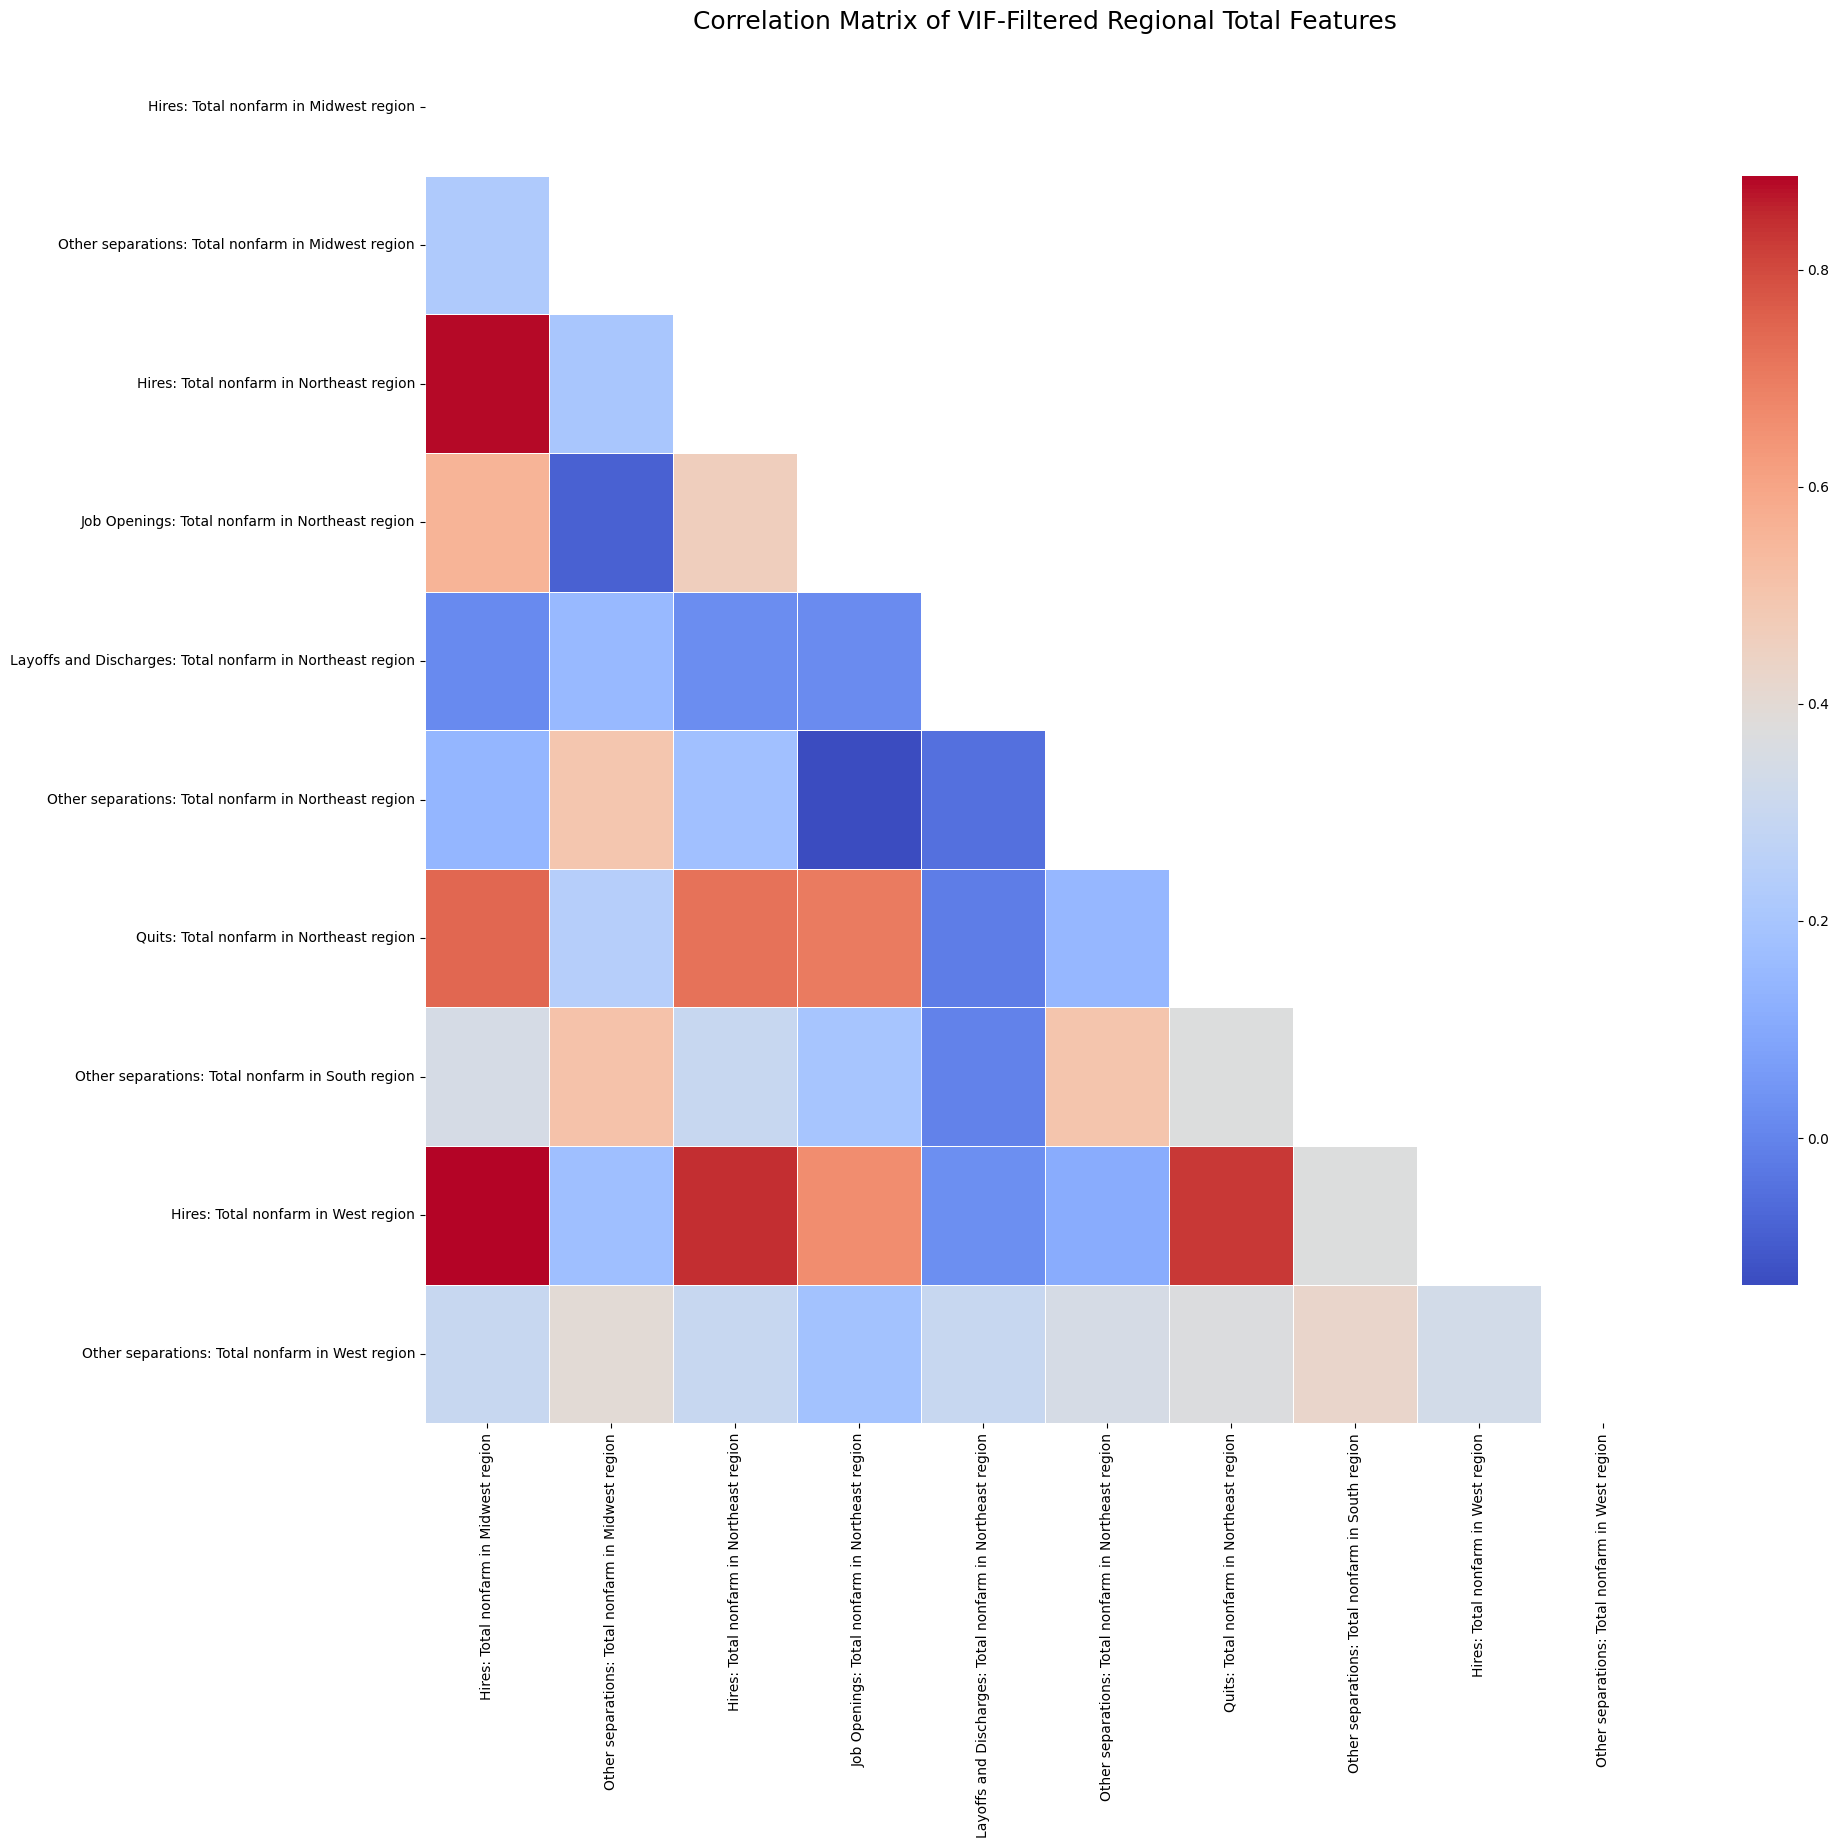

In [71]:
### Create correlation matrix similar to above for regional-level totals
# Assuming final_features_df_regional is the cleaned DataFrame from the VIF function
# 1. Calculate the correlation matrix
## 1a. Shorten column names for better visualization
final_features_df_regional.columns = final_features_df_regional.columns.str.replace(r' - .*', '', regex=True)
corr_matrix = final_features_df_regional.corr()
# 2. Set up the figure size
plt.figure(figsize=(20, 18))
# 3. Create the heatmap
# Use a diverging color map ('coolwarm') and mask the upper triangle for clarity   
mask = np.triu(corr_matrix) # Helper to mask the upper triangle
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=False, # Set to True if you want numbers, but with many features it's too dense
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Matrix of VIF-Filtered Regional Total Features', fontsize=18)
plt.show()

In [97]:
final_features_df_regional.to_csv('data/potential_model_features/regional_level_totals.csv', index=False)

In [70]:
# --- Scope 3: Broad Scope (National Totals) ---
# Goal: Keep columns that represent the absolute National Total (e.g., 'Hires: Total nonfarm - Level in Thousands...').
# Logic: Must contain TOTAL_NONFARM_INDUSTRY AND NOT contain any specific state or region name.

national_total_columns = [
    col for col in df.columns 
    if TOTAL_NONFARM_INDUSTRY in col and
       not contains_any(col, STATE_NAMES) and
       not contains_any(col, REGION_NAMES) #and
       #' in ' not in col # Ensures it's the national total without any 'in [location]' breakdown
]

X_national = df[national_total_columns].copy()
final_features_df_national, final_vifs_national = drop_redundant_vif_features(X_national, threshold=10.0)

Dropping 'Total Separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 7601441.89)

All VIFs are now below the threshold.


### REDO: The last one didn't have any columns lol

In [76]:
# --- Scope 3: Broad Scope (National Totals) ---
# Goal: Keep columns that represent the absolute National Total (e.g., 'Hires: Total nonfarm - Level in Thousands...').
# Logic: Must contain TOTAL_NONFARM_INDUSTRY AND NOT contain any specific state or region name.

national_total_columns = [
    col for col in df.columns 
    if 'Total' in col and
       not contains_any(col, STATE_NAMES) and
         not contains_any(col, REGION_NAMES)
]

X_national = df[national_total_columns].copy()
final_features_df_national, final_vifs_national = drop_redundant_vif_features(X_national, threshold=10.0)

Dropping 'Total Separations: Total private - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 28509824.22)
Dropping 'Total Separations: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 18514081.08)
Dropping 'Layoffs and Discharges: Total private - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 10102214.52)
Dropping 'Job Openings: Total private - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 9809632.71)
Dropping 'Layoffs and Discharges: Total nonfarm - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 6335752.08)
Dropping 'Total Separations: Leisure and hospitality - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 2863592.65)
Dropping 'Total Separations: Total private - Level in Thousands, Monthly, Not Seasonally Adjusted (10 to 49 employees)' (VIF: 1891155.07)
Dropping 'Hires: Total priva

In [77]:
final_vifs_national

,feature,VIF
10,Job Openings: Total private - Level in Thousan...,9.331047
21,"Total Separations: Transportation, warehousing...",8.550080
20,Total Separations: Retail trade - Level in Tho...,8.447006
25,Total Separations: Professional and business s...,8.133124
26,"Total Separations: Arts, entertainment, and re...",7.619100
11,Layoffs and Discharges: Total private - Level ...,7.612326
18,Total Separations: Nondurable goods manufactur...,7.560489
5,"Hires: Total private - Level in Thousands, Mon...",7.027321
7,"Hires: Total private - Level in Thousands, Mon...",6.748018
9,"Hires: Total private - Level in Thousands, Mon...",6.394443


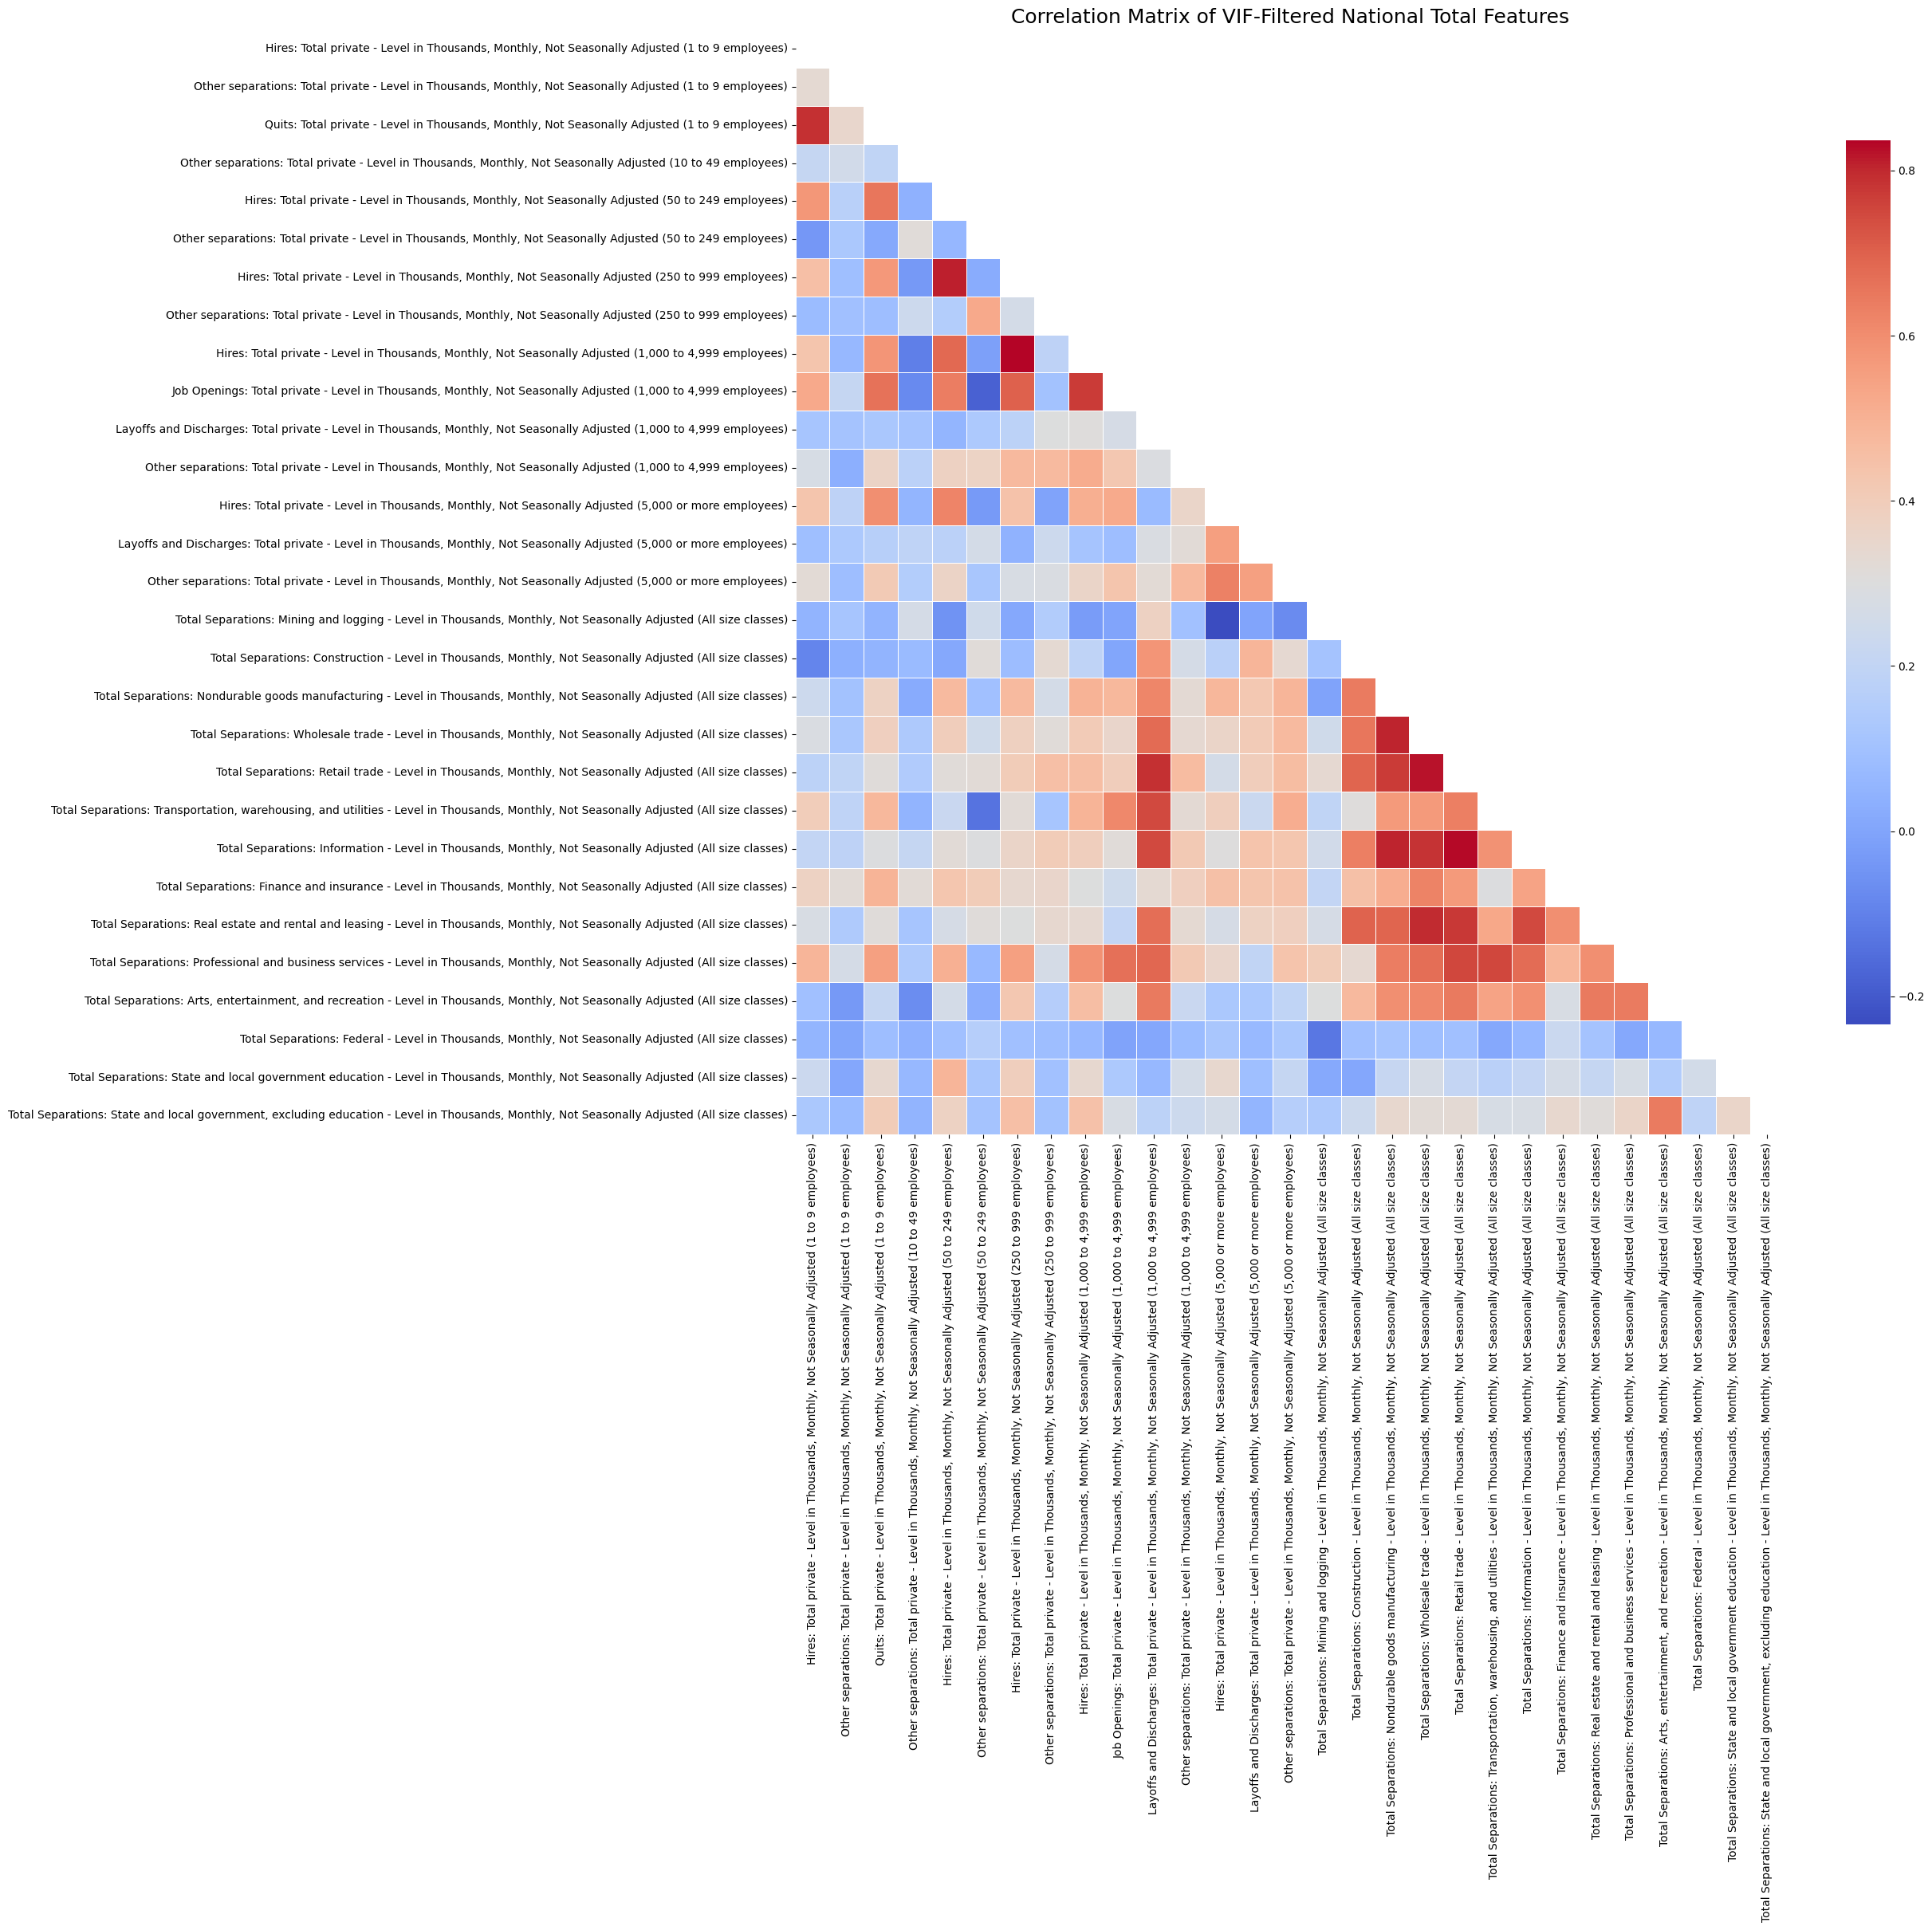

In [78]:
### Plot the correlation matrix for national totals
# Assuming final_features_df_national is the cleaned DataFrame from the VIF function
# 1. Calculate the correlation matrix
## 1a. Shorten column names for better visualization
#final_features_df_national.columns = final_features_df_national.columns.str.replace(r' - .*', '', regex=True)
corr_matrix = final_features_df_national.corr()
# 2. Set up the figure size
plt.figure(figsize=(20, 18))
# 3. Create the heatmap
# Use a diverging color map ('coolwarm') and mask the upper triangle for clarity   
mask = np.triu(corr_matrix) # Helper to mask the upper triangle
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=False, # Set to True if you want numbers, but with many features it's too dense
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Matrix of VIF-Filtered National Total Features', fontsize=18)
plt.show()

In [98]:
final_features_df_national.to_csv('data/potential_model_features/national_level_totals.csv', index=False)

In [94]:
industry_total_columns = [
    col for col in df.columns 
    if not "Total" in col
]

X_industry = df[industry_total_columns].copy()
final_features_df_industry, final_vifs_industry = drop_redundant_vif_features(X_industry, threshold=10.0)

final_vifs_industry


Dropping 'Layoffs and Discharges: Leisure and hospitality - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 3583089.10)
Dropping 'Job Openings: Private education and health services - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 2031809.43)
Dropping 'Job Openings: Trade, transportation, and utilities - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 1243150.74)
Dropping 'Job Openings: Leisure and hospitality - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 1116274.81)
Dropping 'Job Openings: Government - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 525462.52)
Dropping 'Layoffs and Discharges: Trade, transportation, and utilities - Level in Thousands, Monthly, Not Seasonally Adjusted (All size classes)' (VIF: 395623.31)
Dropping 'Hires: Leisure and hospitality - Level in Thousands, Monthly, Not Seasonally Adjusted (All size cla

,feature,VIF
13,"Hires: Wholesale trade - Level in Thousands, M...",8.995334
15,Layoffs and Discharges: Wholesale trade - Leve...,8.941288
26,Layoffs and Discharges: Information - Level in...,8.097006
19,Job Openings: Retail trade - Level in Thousand...,7.759283
42,Quits: Private educational services - Level in...,7.647054
...,...,...
8,Other separations: Construction - Level in Tho...,1.608395
51,Other separations: Other services - Level in T...,1.546908
48,Other separations: Accommodation and food serv...,1.519607
23,"Other separations: Transportation, warehousing...",1.492414


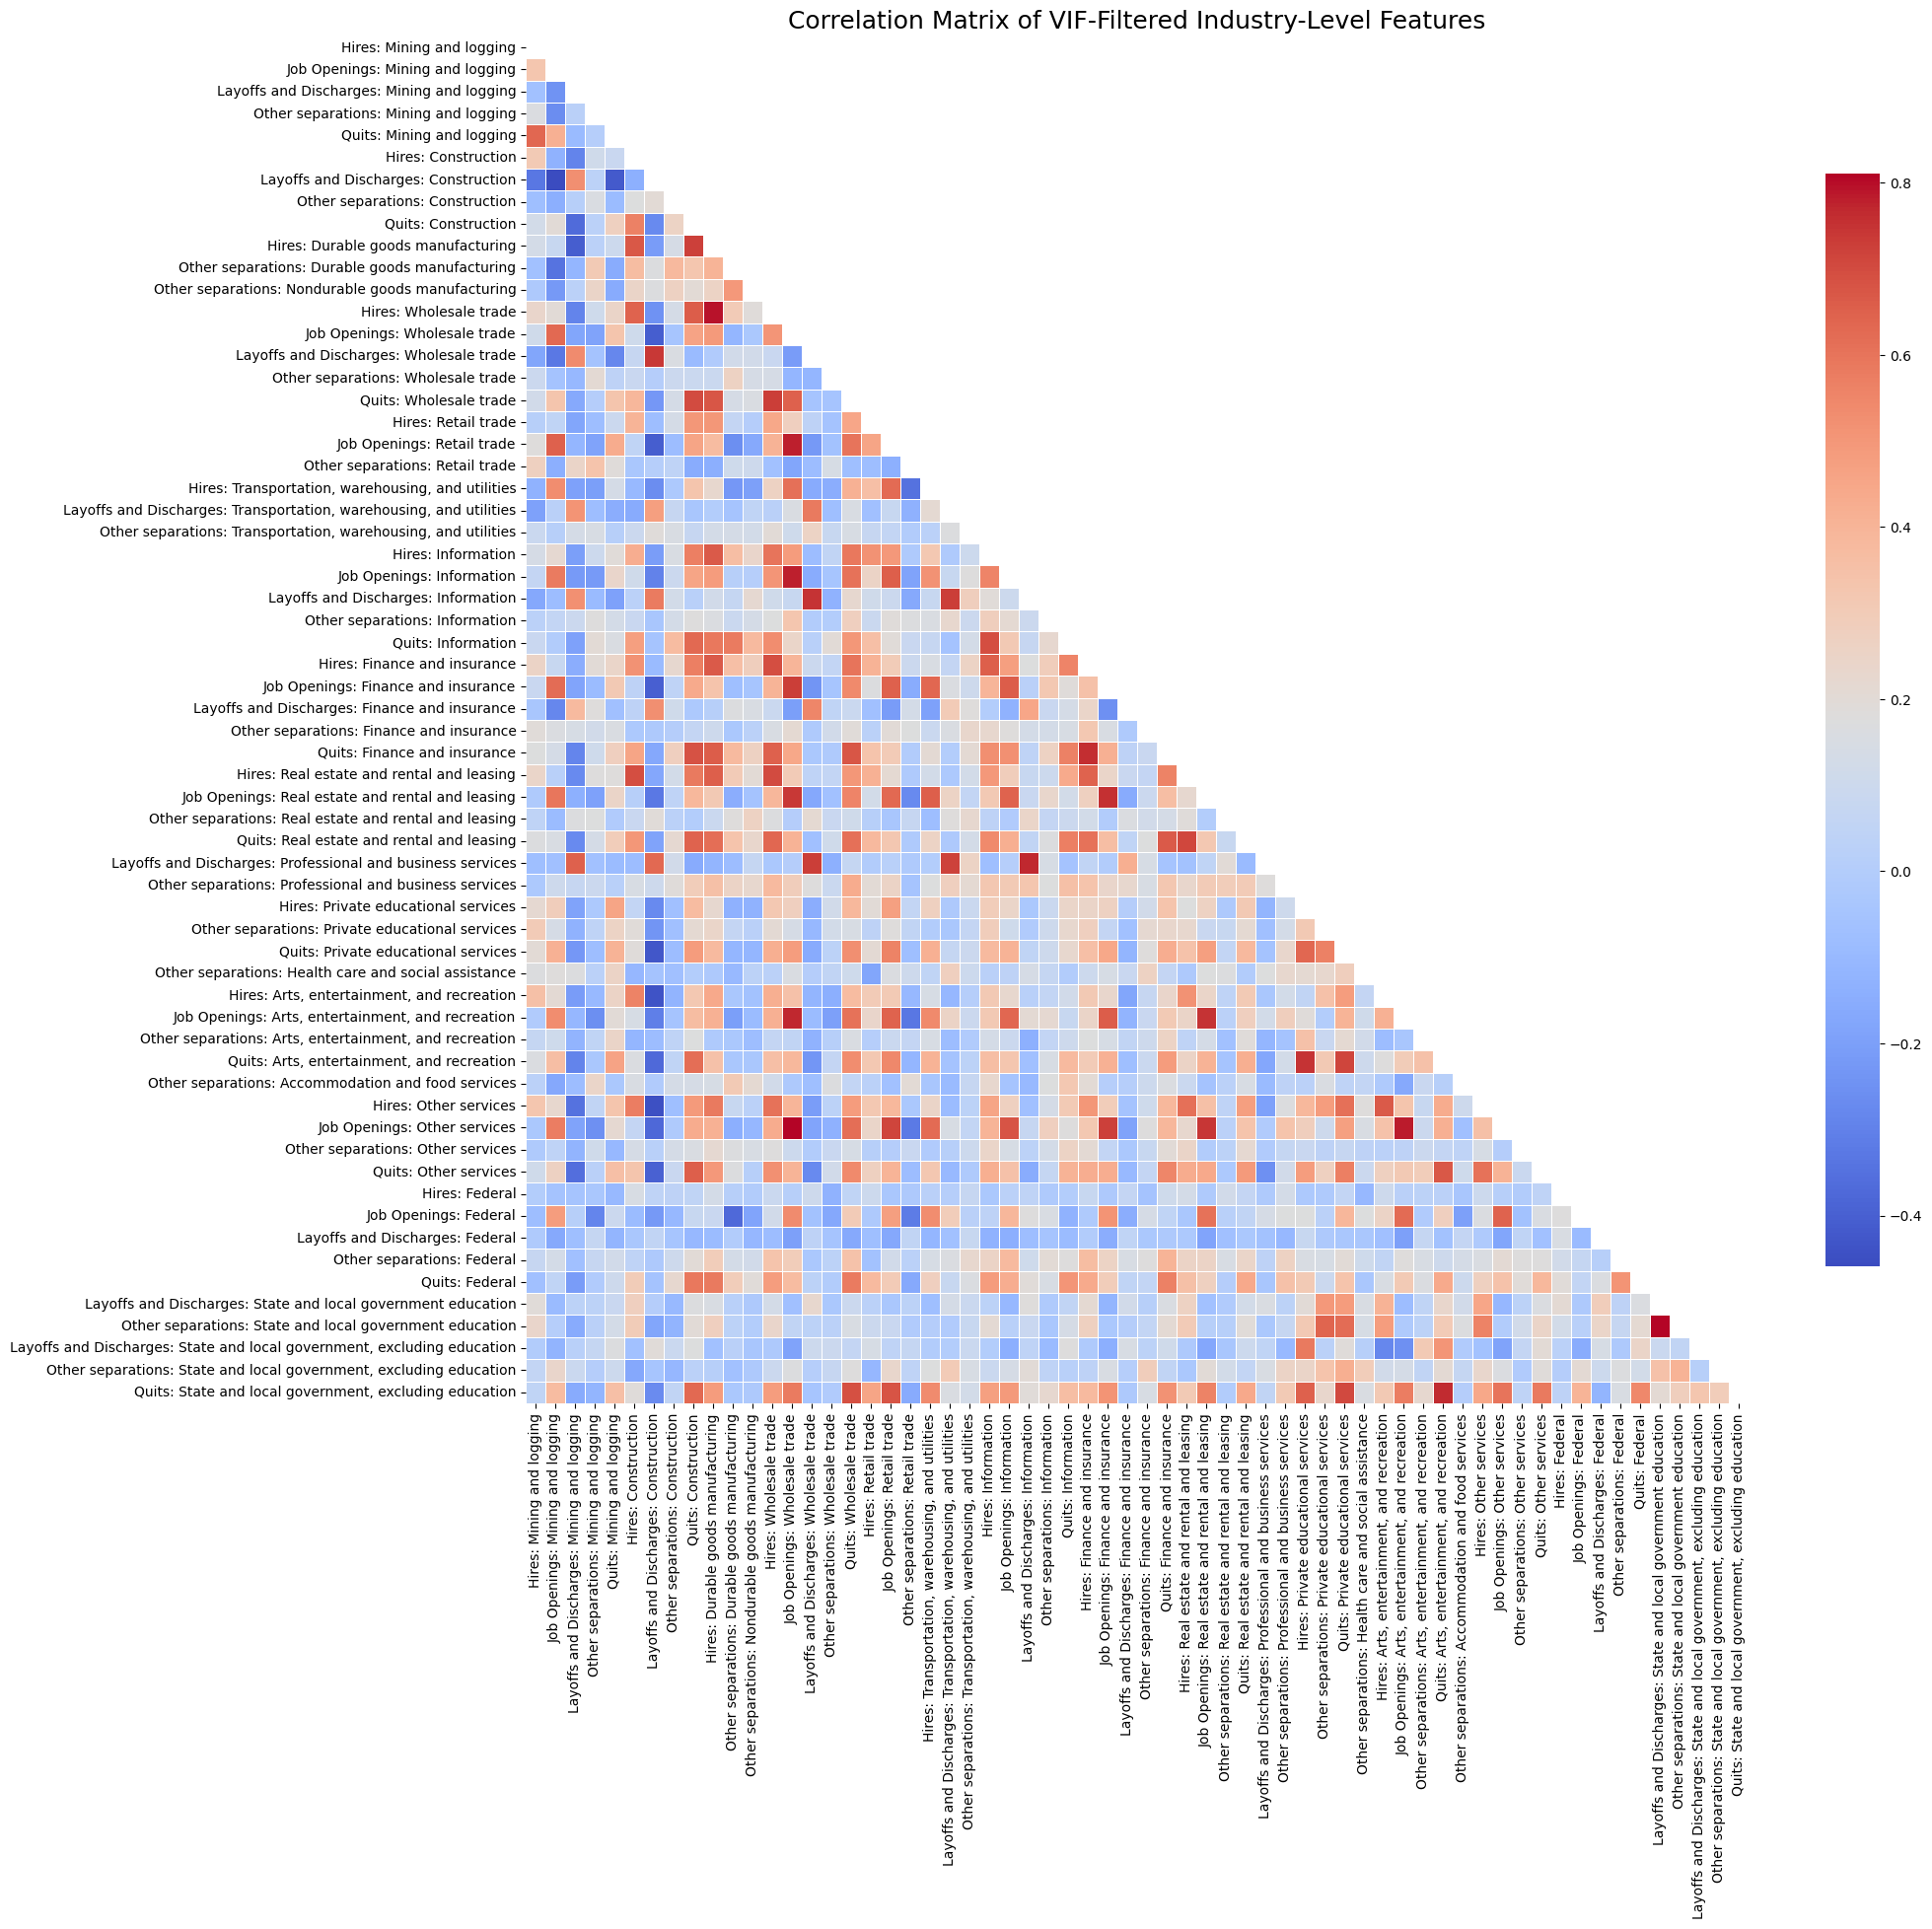

In [95]:
### Plot correlation matrix similar to above for national-level totals
# Assuming final_features_df_industry is the cleaned DataFrame from the VIF function
# 1. Calculate the correlation matrix
## 1a. Shorten column names for better visualization
final_features_df_industry.columns = final_features_df_industry.columns.str.replace(r' - .*', '', regex=True)
corr_matrix = final_features_df_industry.corr()
# 2. Set up the figure size
plt.figure(figsize=(20, 18))
# 3. Create the heatmap
# Use a diverging color map ('coolwarm') and mask the upper triangle for clarity
mask = np.triu(corr_matrix) # Helper to mask the upper triangle
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=False, # Set to True if you want numbers, but with many features it's too dense
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)      
plt.title('Correlation Matrix of VIF-Filtered Industry-Level Features', fontsize=18)
plt.show()

In [99]:
final_features_df_industry.to_csv('data/potential_model_features/industry_level_totals.csv', index=False)